Nama : Ken Foster Morintoh\
NIM  : 672020175

Clustering
1. K-means clustering
2. Hierarichl clustering 
3. DBScan



Refff : 
**Heirarichal clustering (Agloromerative clustering)**\
https://www.datacamp.com/tutorial/introduction-hierarchical-clustering-python
https://www.w3schools.com/python/python_ml_hierarchial_clustering.asp
https://www.analyticsvidhya.com/blog/2019/05/beginners-guide-hierarchical-clustering/
https://medium.com/@muratgulcan/hierarchical-clustering-with-python-basic-concepts-and-application-cd5f5dc95b1f
https://www.geeksforgeeks.org/hierarchical-clustering/
https://www.kaggle.com/code/riyadhrazzaq/hierarchical-clustering-scratch
https://towardsdatascience.com/implement-agglomerative-hierarchical-clustering-with-python-e2d82dc69eeb

**K-Means**\
https://www.geeksforgeeks.org/k-means-clustering-introduction/
https://towardsdatascience.com/k-means-clustering-algorithm-applications-evaluation-methods-and-drawbacks-aa03e644b48a
https://www.kaggle.com/code/prashant111/k-means-clustering-with-python
https://nzlul.medium.com/unsupervised-learning-k-means-clustering-using-python-case-online-retail-dataset-df7d18599a52

**DB-Scan**\
https://www.geeksforgeeks.org/dbscan-clustering-in-ml-density-based-clustering/
https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html
https://www.kaggle.com/code/bagavathypriya/dbscan-clustering
https://medium.com/@revag2014/dbscan-an-easy-clustering-algorithm-and-also-how-to-optimize-it-using-grid-search-69a382b63e85


In [17]:
import pandas as pd 
import numpy as np
import seaborn as sbs
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')



In [3]:
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [4]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [5]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='object')

In [6]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [7]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

<Axes: >

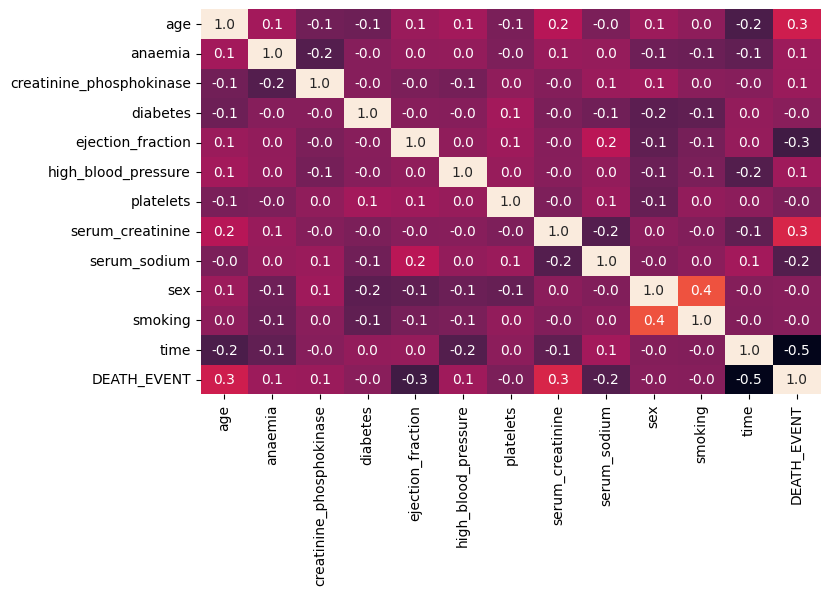

In [8]:
plt.figure(figsize = (8,5))
sbs.heatmap(df.corr(), cbar = False, annot = True, fmt=".1f")

Terlihat bahwa korelasi yang cukup tinggi adalah age dan serum_creatine jadi disini saya memilih dua fitur tersebut untuk diplot nantiny

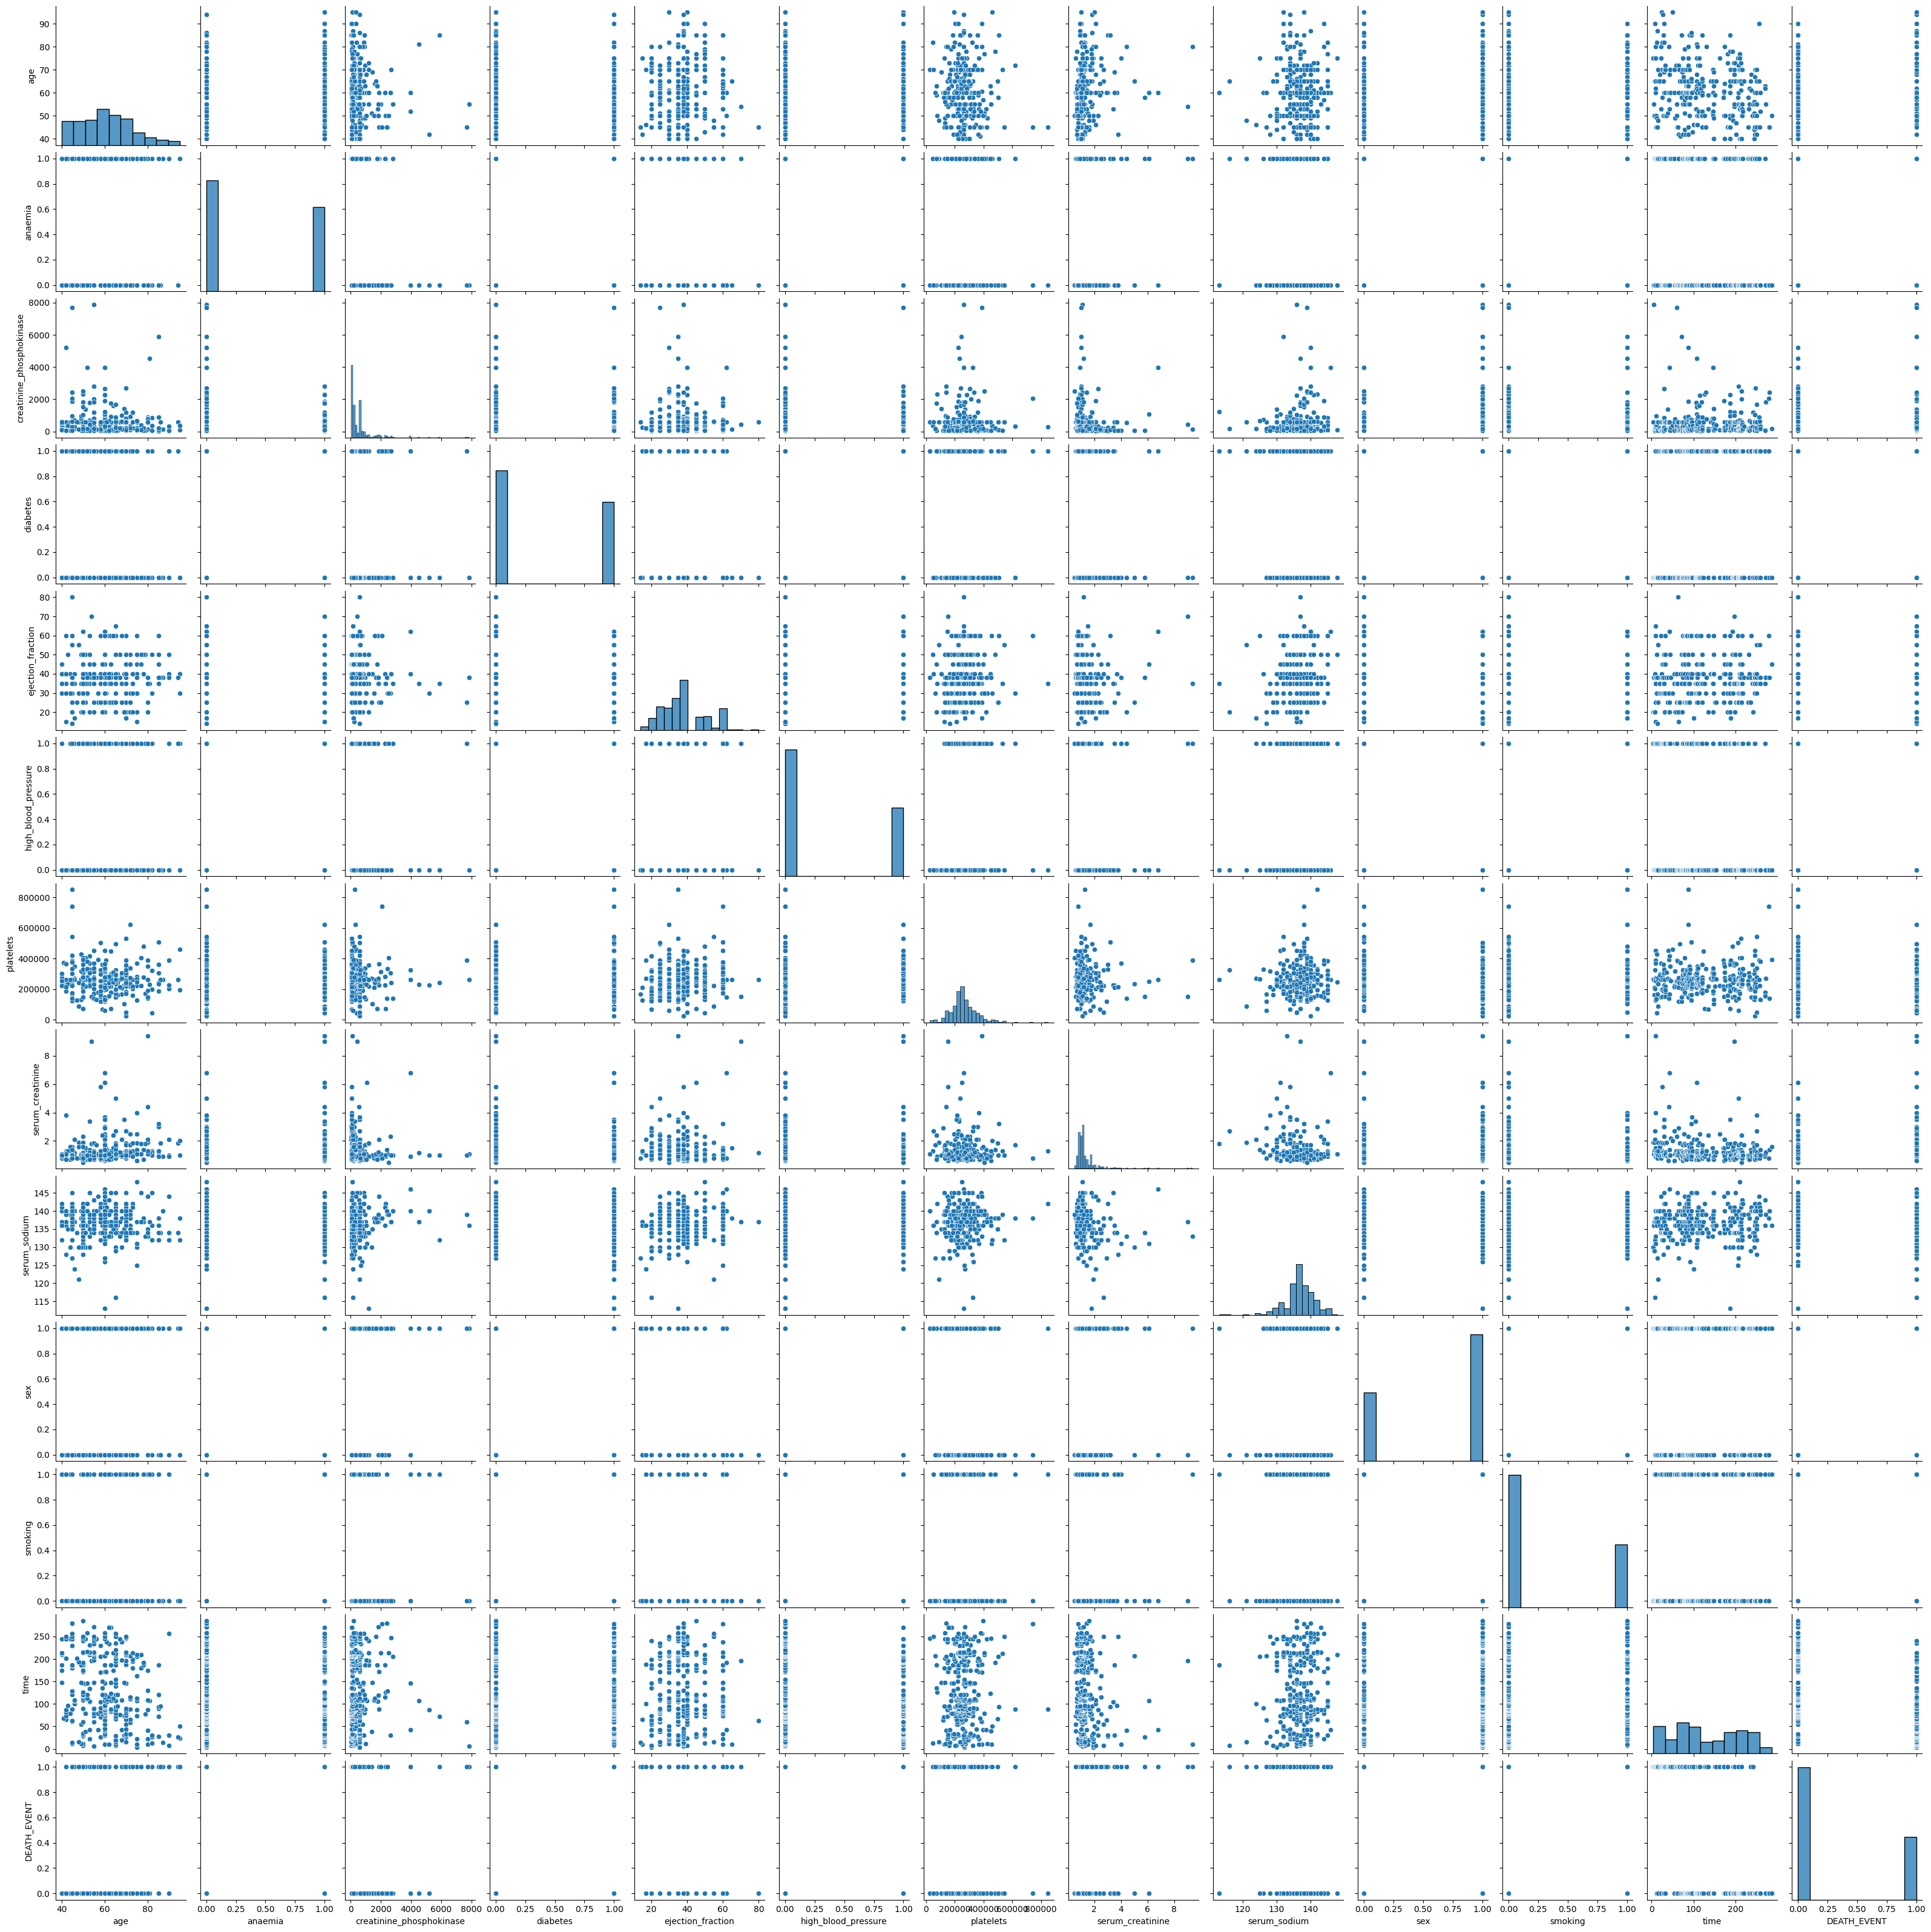

In [9]:
sbs.pairplot(df)

In [10]:
feature = df.drop(columns = ['DEATH_EVENT'])
target = df['DEATH_EVENT']

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_feature = scaler.fit_transform(feature)

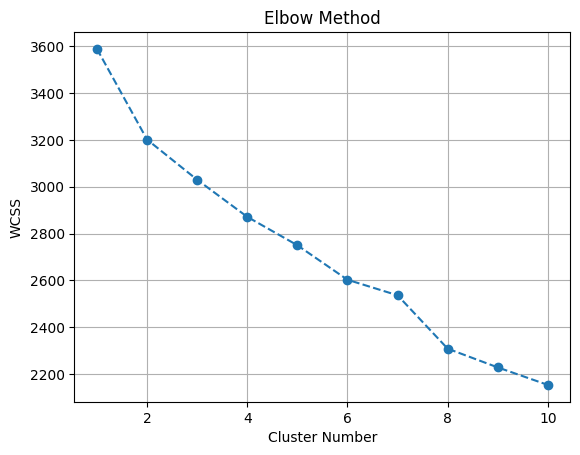

In [12]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(scaled_feature)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1, 11), wcss, marker='o', linestyle = '--')
plt.title('Elbow Method')
plt.xlabel('Cluster Number')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

K = 2 adalah cluster yang cukup baik

In [13]:
kmeans = KMeans(n_clusters=2, 
                init='k-means++', 
                max_iter=300, 
                n_init=10, 
                random_state=0) 
y_kmeans = kmeans.fit_predict(scaled_feature) 


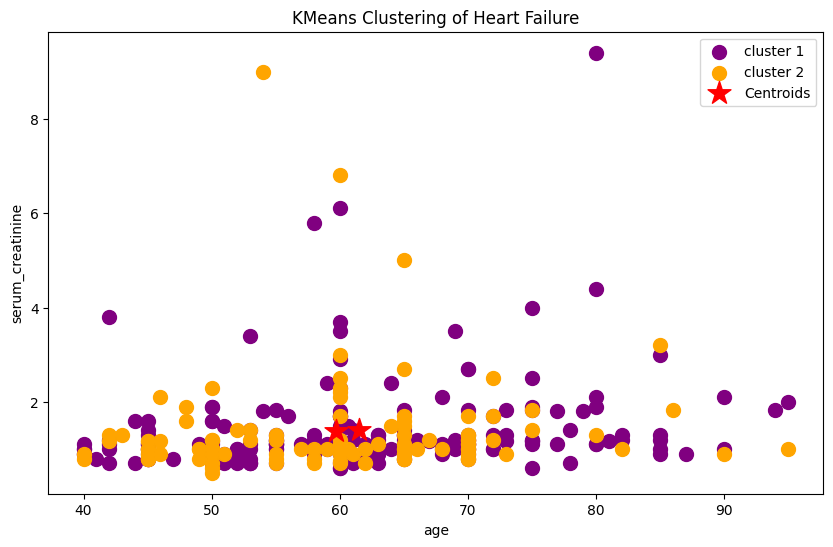

In [15]:
cols = df.columns
# Plot the clusters
plt.figure(figsize=(10, 6))
plt.scatter(df.iloc[y_kmeans == 0, 0], df.iloc[y_kmeans == 0, 7], 
            s=100, c='purple', label='cluster 1') 
plt.scatter(df.iloc[y_kmeans == 1, 0], df.iloc[y_kmeans == 1, 7], 
            s=100, c='orange', label='cluster 2') 


# Plotting the centroids of the clusters 
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, feature.columns.get_loc('age')], centroids[:, feature.columns.get_loc('serum_creatinine')], 
            s=300, c='red', label='Centroids', marker='*')


plt.xlabel(cols[0])
plt.ylabel(cols[7])
plt.legend() 
plt.title('KMeans Clustering of Heart Failure')
plt.show()




**Heirarichal Clustering**

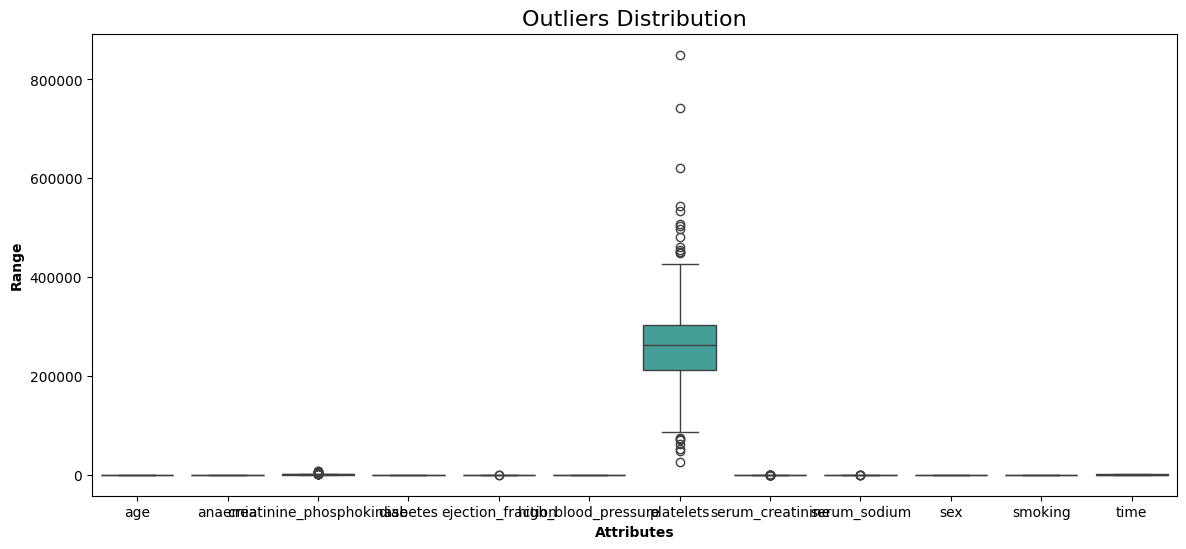

In [18]:
def show_boxplot(df):
    plt.rcParams['figure.figsize'] = [14,6]
    sbs.boxplot(data = df, orient="v")
    plt.title("Outliers Distribution", fontsize = 16)
    plt.ylabel("Range", fontweight = 'bold')
    plt.xlabel("Attributes", fontweight = 'bold')
   
show_boxplot(feature)

In [29]:
#Agar clustering lebih baik dsini saya menghilakan oulier yang ada pada data 
def remove_outliers(data):
   
    df = data.copy()
   
    for col in list(df.columns):
 
      Q1 = df[str(col)].quantile(0.05)
      Q3 = df[str(col)].quantile(0.95)
      IQR = Q3 - Q1
      lower_bound = Q1 - 1.5*IQR
      upper_bound = Q3 + 1.5*IQR
 
      df = df[(df[str(col)] >= lower_bound) & 

        (df[str(col)] <= upper_bound)]
   
    return df


In [30]:
without_outliers = remove_outliers(feature)

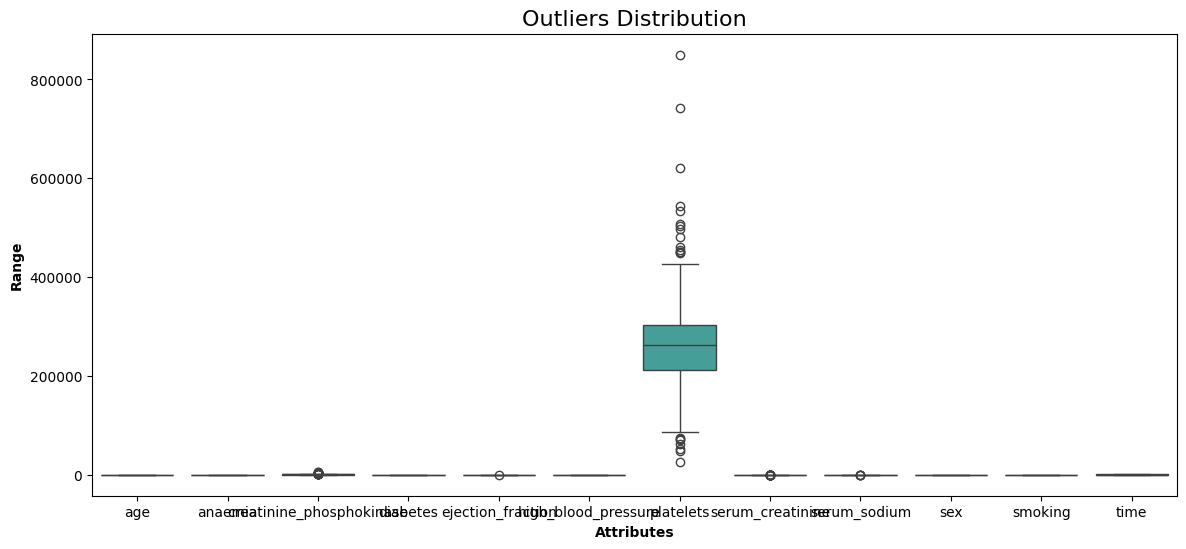

In [31]:
show_boxplot(without_outliers)

In [32]:
from scipy.cluster.hierarchy import linkage, dendrogram

complete_clustering = linkage(scaled_feature, method="complete", metric="euclidean")
average_clustering = linkage(scaled_feature, method="average", metric="euclidean")
single_clustering = linkage(scaled_feature, method="single", metric="euclidean")

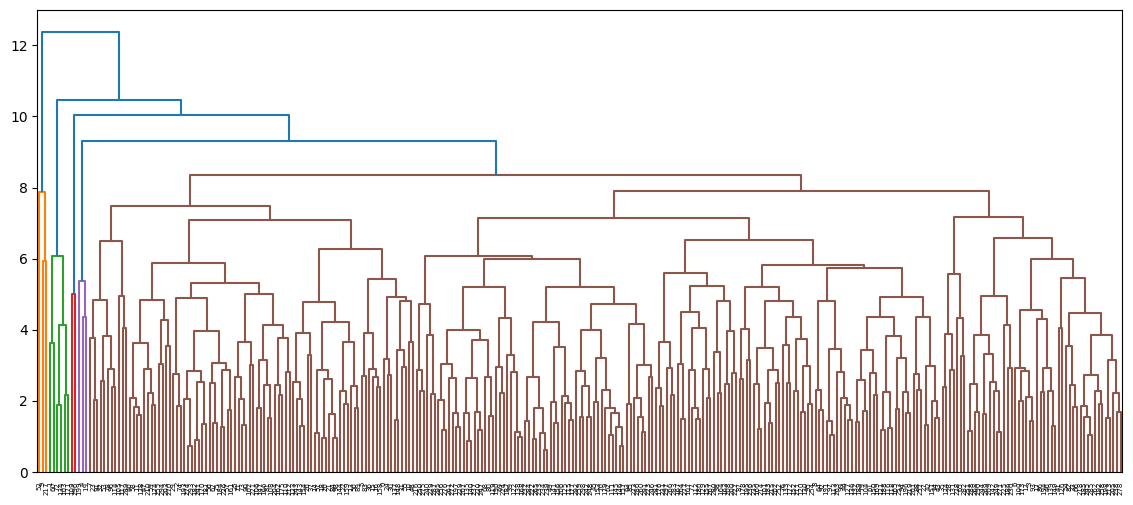

In [33]:
dendrogram(complete_clustering)
plt.show()

Diatas adalah struktur dendogram clustering yang terbentuk

In [38]:
from sklearn.cluster import AgglomerativeClustering
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')

In [39]:
labels = hierarchical_cluster.fit_predict(scaled_feature) 
print(labels)

[0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0 0 0 0 1 1 0 0 0
 1 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0
 0 0 0 1 0 1 1 0 1 0 1 1 0 0 0 0 0 1 1 0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 1 0
 0 1 1 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 1 1 0 1 0 1 1 1 1 0 0 0 1
 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 1 1 1 1 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 0 0 1 0 0 1 0 0 1 1 0
 0 0 1 1 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 0 1 1 0 1 1 1 0 1 0 0 1 0 0
 0 0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1
 1 0 0]


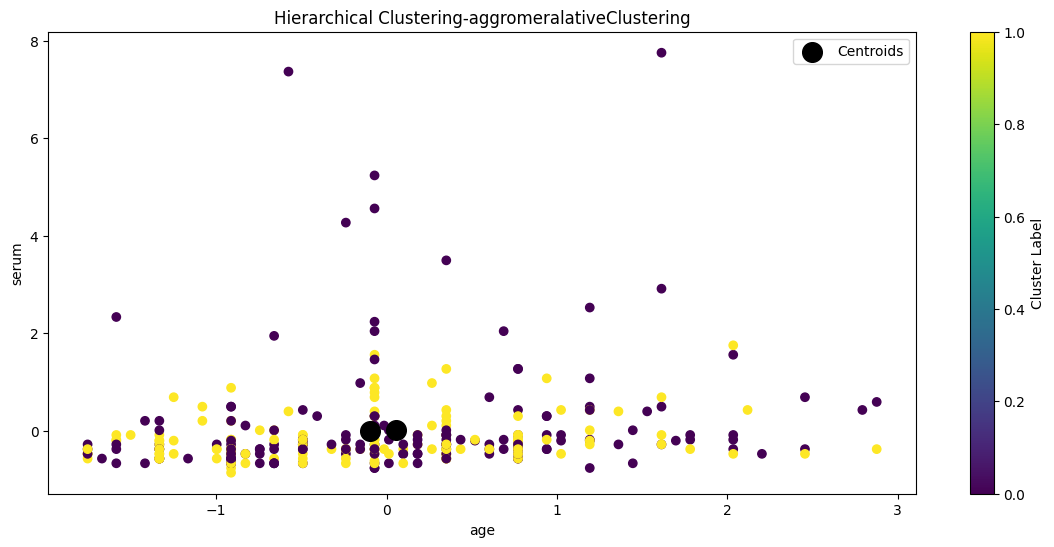

In [49]:
# Plot the clusters
plt.scatter(scaled_feature[:, 0], scaled_feature[:, 7], c=labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 7], s=200, c='black', label='Centroids')
plt.legend()
plt.title('Hierarchical Clustering-aggromeralativeClustering')
plt.xlabel('age')
plt.ylabel('serum')
plt.colorbar(label='Cluster Label')
plt.show()


Dsini sudah terlihat clustering sudah cukup mirip dengan k-mean menandakan clustering hierarchical berhasil

Visualisasi perbandingan ketiga algoritma

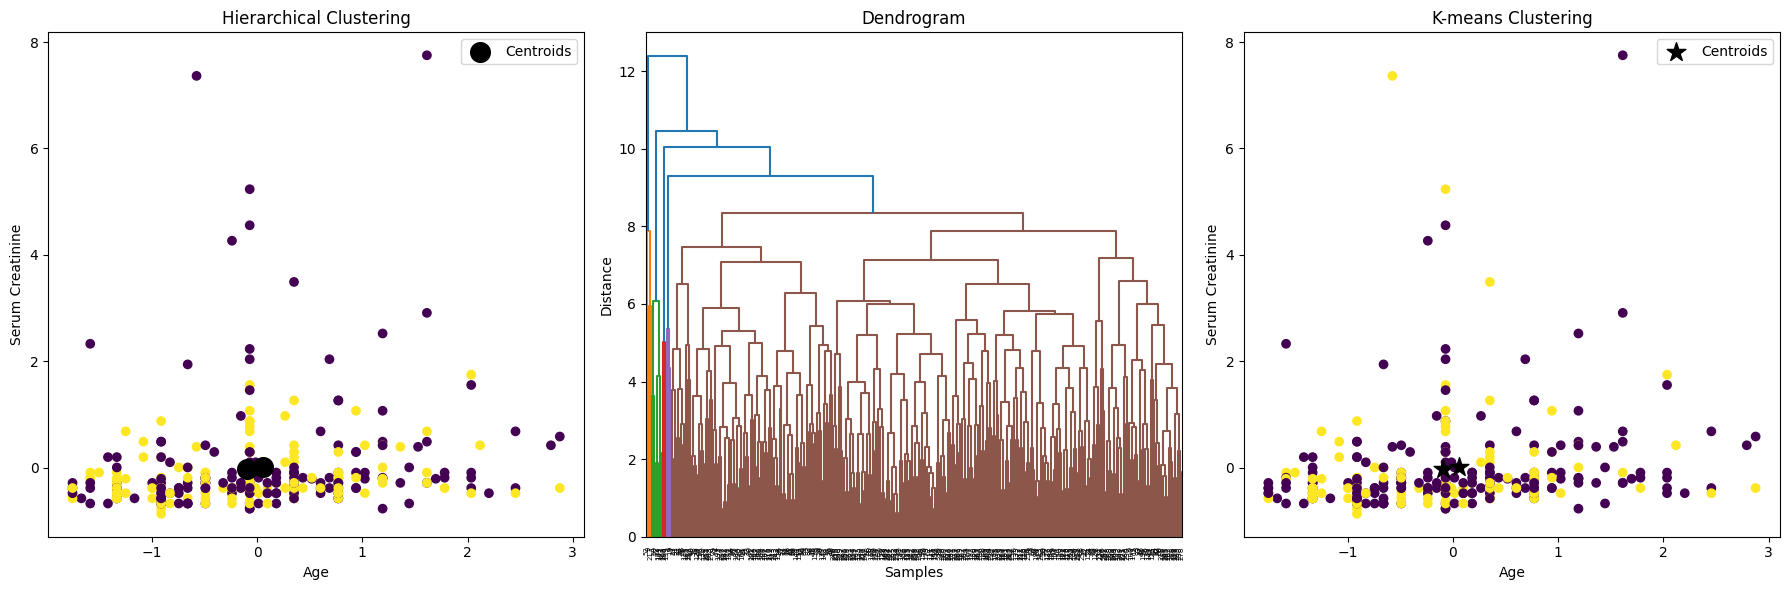

In [60]:

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot hierarchical clustering
axs[0].scatter(scaled_feature[:, 0], scaled_feature[:, 7], c=labels, cmap='viridis')
axs[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 7], s=200, c='black', label='Centroids')
axs[0].set_title('Hierarchical Clustering')
axs[0].set_xlabel('Age')
axs[0].set_ylabel('Serum Creatinine')
axs[0].legend()

# Plot dendrogram
dendrogram(complete_clustering, ax=axs[1])
axs[1].set_title('Dendrogram')
axs[1].set_xlabel('Samples')
axs[1].set_ylabel('Distance')

# Plot K-means clustering
axs[2].scatter(scaled_feature[:, 0], scaled_feature[:, 7], c=y_kmeans, cmap='viridis')
centroids = kmeans.cluster_centers_
axs[2].scatter(centroids[:, 0], centroids[:, 7], s=200, c='black', marker ='*', label='Centroids')
axs[2].set_title('K-means Clustering')
axs[2].set_xlabel('Age')
axs[2].set_ylabel('Serum Creatinine')
axs[2].legend()

plt.tight_layout()
plt.show()

In [65]:
from sklearn.preprocessing import normalize 
X_normalized = normalize(scaled_feature)

  
# Converting the numpy array into a pandas DataFrame 
X_normalized = pd.DataFrame(X_normalized) 


In [66]:
from sklearn.decomposition import PCA

In [83]:

pca = PCA(n_components = 2) 
X_principal = pca.fit_transform(X_normalized) 
X_principal = pd.DataFrame(X_principal) 
X_principal.columns = ['P1', 'P2'] 
print(X_principal.head()) 

         P1        P2
0  0.108466  0.631545
1  0.119674 -0.037738
2  0.601321  0.304854
3  0.135870  0.253575
4 -0.244344  0.155040


In [84]:
from sklearn.cluster import DBSCAN 
# Numpy array of all the cluster labels assigned to each data point 
db_default = DBSCAN(eps = 0.0375, min_samples = 3).fit(X_principal) 
labels = db_default.labels_ 

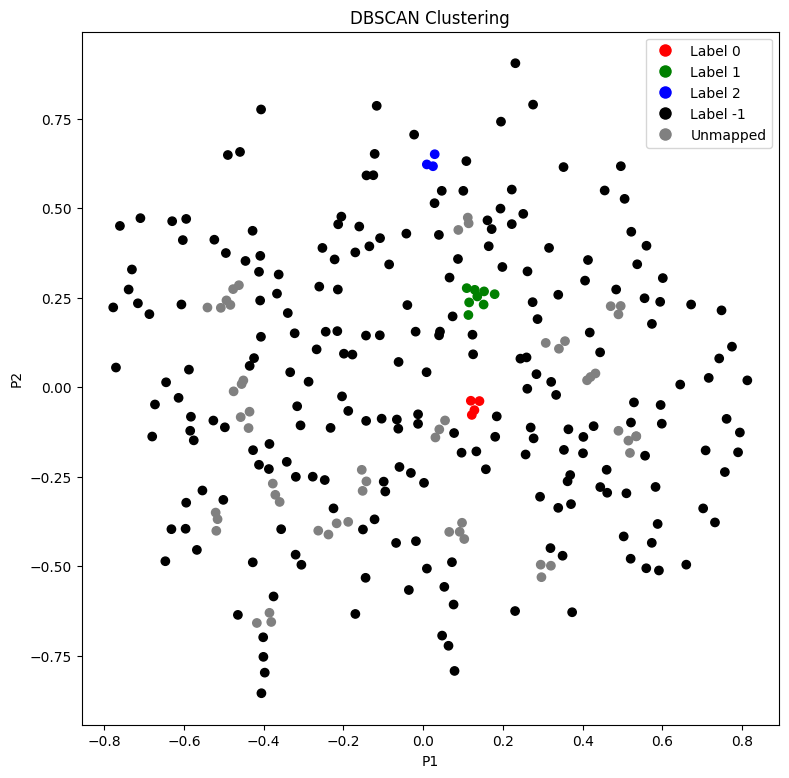

In [86]:
import matplotlib.pyplot as plt

# Assuming `labels` and `X_principal` are already defined

# Building the label to colour mapping 
colours = {0: 'r', 1: 'g', 2: 'b', -1: 'k'}

# Define a default color for unmapped labels
default_color = 'grey'

# Building the colour vector for each data point
cvec = [colours.get(label, default_color) for label in labels]

# Plotting P1 on the X-Axis and P2 on the Y-Axis 
# according to the colour vector defined 
plt.figure(figsize=(9, 9))
plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)

# For the construction of the legend of the plot 
# Creating proxy artists for the legend
r = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='r', markersize=10)
g = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='g', markersize=10)
b = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='b', markersize=10)
k = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=10)
grey = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markersize=10)

# Building the legend 
plt.legend((r, g, b, k, grey), ('Label 0', 'Label 1', 'Label 2', 'Label -1', 'Unmapped'))

plt.xlabel('P1')
plt.ylabel('P2')
plt.title('DBSCAN Clustering')

plt.show()


In [87]:
db = DBSCAN(eps = 0.0375, min_samples = 50).fit(X_principal) 
labels1 = db.labels_ 

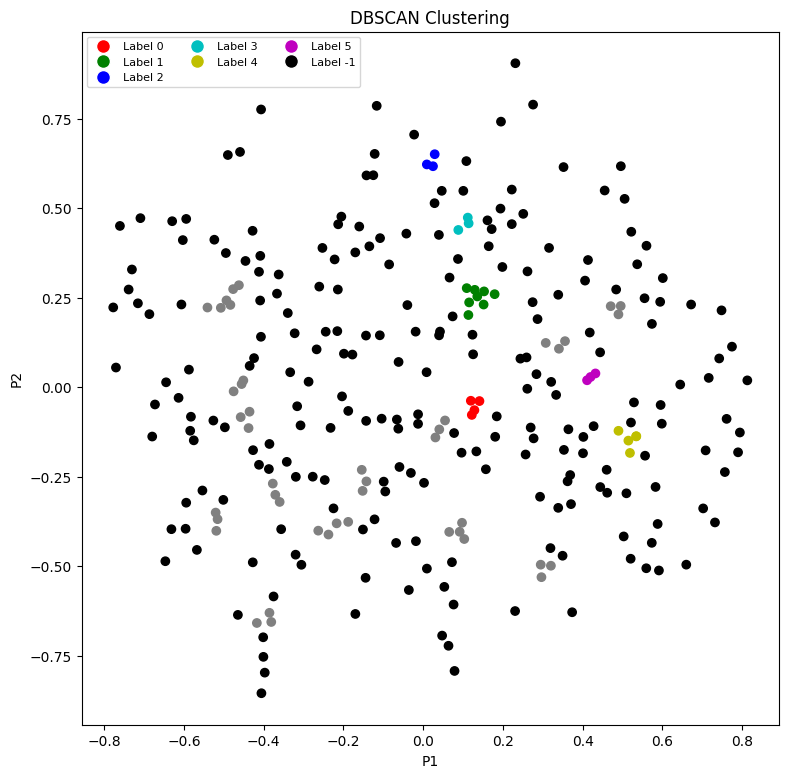

In [95]:

import matplotlib.pyplot as plt


colours1 = {0: 'r', 1: 'g', 2: 'b', 3: 'c', 4: 'y', 5: 'm', -1: 'k'}

default_color = 'grey'

cvec = [colours1.get(label, default_color) for label in labels]


plt.figure(figsize=(9, 9))
scatter = plt.scatter(X_principal['P1'], X_principal['P2'], c=cvec)

legend_labels = ['Label 0', 'Label 1', 'Label 2', 'Label 3', 'Label 4', 'Label 5', 'Label -1']
colors = ['r', 'g', 'b', 'c', 'y', 'm', 'k']
legend_proxies = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10) for color in colors]

plt.legend(legend_proxies, legend_labels, scatterpoints=1, loc='upper left', ncol=3, fontsize=8)

plt.xlabel('P1')
plt.ylabel('P2')
plt.title('DBSCAN Clustering')

plt.show()
